# Individual Energy-Profile Prediction — curve-approach evaluation

The per-activity **individual curve** prediction benchmark (Baseline, ML DTW,
ML + Ext. Factors, Seq2Seq, …) — the same evaluation as in `results_latex_table`,
extracted on its own.

- Source: `curve_eval_results.parquet` (per-curve records with an **Activity**
  dimension, unlike the `summary_train_test` file the old notebook used).
- Granularity: aggregated **process × activity × sensor**, then across those with
  the **median** (metrics: sMAE, sRMSE, WAPE).
- One table **per process** (all methods) + one **aggregated** table (all
  processes), both as styled tables and LaTeX.
- **Boxplots** of the aggregated per-(process, activity, sensor) values, in the
  same style as the sMAE boxplot in `results_latex_table`.

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from IPython.display import display, Markdown

EXPERIMENT = 984
SPLIT      = 'TEST'                       # 'TEST' or 'TRAIN'
METRICS    = ['sMAE', 'sRMSE', 'WAPE']    # WAPE is a percentage
BOX_METRIC = 'sMAE'                       # metric for the boxplots
EXCLUDE_APPROACHES = []                   # e.g. ['ML only (no DTW)'] to drop variants
SAVE_LATEX = True

# ── Realism metrics ──────────────────────────────────────────────────────────
# Every metric in METRICS is POINTWISE, and pointwise error cannot tell a usable
# load profile from a flat line drawn through the middle of one. It actively
# prefers the flat line: sMAE z-scores by the true curve and takes a mean
# absolute deviation, so a smooth prediction through a spiky signal scores well.
# That is why the averaging approaches win it while emitting roughly a tenth of
# the real variation, and it is why these have to be read alongside it.
#
# Identical logic to results_complete_energy_profile.ipynb: each metric is the
# NORMALISED ABSOLUTE ERROR of a property of the predicted curve against the same
# property of the real one,
#
#     err = |f_pred - f_real| / scale,   scale = mean|f_real| over that
#                                                (process, sensor)'s real curves
#
# so 0 = perfect and LOWER IS BETTER, exactly like sMAE/WAPE and exactly like the
# complete-profile notebook. Same names, same formula, same direction, so 'Std'
# means the same number in both notebooks. 'Overall' (added to the tables below)
# is the plain average across the metric columns, as it is there.
#
# Why normalised rather than the ratio f_pred/f_real this notebook used before:
#   * the ratio's denominator is THAT CURVE'S OWN f_real, so a near-flat real
#     curve (std_real ~ 0) explodes or has to be dropped. Dividing by the
#     sensor's TYPICAL real magnitude is robust to individual degenerate curves.
#   * the ratio is asymmetric: 0.5 and 2.0 are both "factor 2 wrong" but sit 0.5
#     and 1.0 from 1.0, so a median of ratios UNDER-penalises flatness — exactly
#     the failure these metrics exist to expose.
# Both are unitless, so either supports the cross-sensor aggregate table that raw
# values could never support (degC, bar and kW in one column).
#
# The cost of the absolute value is DIRECTION: 'Std' 0.20 says the spread is off
# by a fifth of the sensor's typical spread, not whether the curve is too flat or
# too excited. Every approach in this data is too flat; add a signed companion
# column if that stops being true.
#
# 'Sum' is derived as mean x N in the load cell — see there. AC1 and the
# duty-cycle/zero-fraction metric are deliberately absent; duty cycle is measured
# properly, relative to each curve's own range, in the complete-profile notebook.
#
#   name -> (predicted column, real column, target)
REALISM_SPECS = {
    'Sum':       ('sum_pred',   'sum_real',   0.0),   # total energy over the curve (= mean x N)
    'Max':       ('max_pred',   'max_real',   0.0),   # peak, which sizes equipment and tariffs
    'Mean':      ('mean_pred',  'mean_real',  0.0),   # average load level, i.e. the bias
    'Std':       ('std_pred',   'std_real',   0.0),   # spread — THE flatness measure
    'Roughness': ('rough_pred', 'rough_real', 0.0),   # jaggedness: catches the OPPOSITE failure to
                                                      # 'Std' -- right amplitude reached by adding
                                                      # noise rather than real dynamics
}
REALISM        = list(REALISM_SPECS)
REALISM_TARGET = {k: v[2] for k, v in REALISM_SPECS.items()}

# These need the per-curve shape statistics sim_extractor._curve_shape_stats
# writes into curve_eval_results.parquet. Runs produced BEFORE that existed
# (experiment_969 and earlier) stored only the five pointwise metrics, so every
# realism section below detects the missing columns and skips itself with a note
# instead of failing. Re-run the pipeline to populate them.

# ── Levelling: two independent ways the approaches are scored on different
#    populations. Both are on by default; turn either off to see the raw
#    behaviour. Section 0 verifies the result and complains if anything is left.

# 1) Curve-length floor, applied to EVERY approach before any table or figure.
# The pipeline does not score the same curves for every approach: the
# *_external ones are evaluated through split_curves_with_prev_activity, which
# keeps curves with >= 5 samples, while every other approach goes through
# split_curves, which keeps >= 2. Curves 2-4 samples long therefore exist for
# six approaches and not for the two prev-activity ones (experiment_964:
# 30,080 vs 26,000 TEST curves), so the raw columns are medians over different
# populations. Filtering here levels them; set to 0 to see the raw behaviour.
MIN_CURVE_POINTS = 5

# 2) Cell coverage. MIN_CURVE_POINTS equalises curve *length*, not WHICH
# (process, activity, sensor) cells an approach is scored on — and the Baseline
# is not scored on the same ones. It is the median curve of a sensor, so it
# exists for every activity, while a learned approach only has a pipeline where
# there was enough training data to fit one. In experiment_968 that left the
# Baseline holding 442 cells / 19,739 TEST curves against 390 / 19,681 for the
# other seven, and its 52 extra cells are the hard ones (median sMAE 3.5, max
# 63.9): the Baseline row was being penalised for activities no other method was
# ever asked to predict. Restricting to the cells every approach owns makes the
# populations identical — same curves, same cells, same non-NaN cells per metric.
LEVEL_CELL_COVERAGE = True

# ── Method names as they should read everywhere (tables, LaTeX, boxplots) ────
# Keys are the raw `Approach` values in curve_eval_results.parquet; anything not
# listed keeps its raw name. Applied right after loading, so every downstream
# table and figure uses these names. NOTE: the raw 'Median per Activity & Sensor'
# must not survive into LaTeX — a bare '&' would be read as a column separator.
METHOD_RENAME = {
    'ML + Ext. Factors':                       'DTW + ML + Ext. Factors',
    'ML DTW':                                  'DTW + ML',
    'Median per Activity & Sensor':            'Median per activity and sensor',
    'DTW + Seq2Seq + Ext. Factors':            'DTW + Seq2Seq + Ext. Factors',
    'Exemplar (real curve)':                   'Exemplar (real curve)',
}

results_root = Path('..') / 'results'
runs = sorted([d for d in results_root.iterdir()
               if d.is_dir() and d.name.startswith(f'experiment_{EXPERIMENT}_')])
assert runs, f'No runs for experiment {EXPERIMENT}'
run_dir = runs[-1]
print('Using run:', run_dir.name)

Using run: experiment_982_20260727_085137


In [2]:
# ── Load + aggregate to (process, activity, sensor, approach) ────────────────
raw = pd.read_parquet(run_dir / 'curve_eval_results.parquet')
raw = raw[raw['Split'] == SPLIT]
if EXCLUDE_APPROACHES:                       # exclusion uses the RAW names
    raw = raw[~raw['Approach'].isin(EXCLUDE_APPROACHES)]

# ── Real test curves — stored once, joined back here ─────────────────────────
# y_pred lives on every scored row (it differs per approach); y_true does NOT,
# because every approach is scored on the SAME curves and repeating the array
# once per approach was ~half the file duplicated tenfold. modelling.py writes it
# to real_test_curves.parquet keyed on the curve identity; this merge restores
# the pairing so `raw` has both arrays exactly as before.
_real_path = run_dir / 'real_test_curves.parquet'
if 'y_pred' in raw.columns and 'y_true' not in raw.columns and _real_path.exists():
    _real = pd.read_parquet(_real_path)
    _rc_key = [c for c in ['Process', 'Sensor', 'Activity', 'Instance', 'Split']
               if c in raw.columns and c in _real.columns]
    raw = raw.merge(_real[_rc_key + ['y_real']], on=_rc_key, how='left')
    raw = raw.rename(columns={'y_real': 'y_true'})
    print(f'Joined {len(_real):,} real curves from real_test_curves.parquet '
          f'on {" + ".join(_rc_key)}  '
          f'({raw["y_true"].notna().mean()*100:.1f}% of scored rows matched)')
elif 'y_pred' in raw.columns and 'y_true' not in raw.columns:
    print('NOTE: y_pred is present but real_test_curves.parquet is not — '
          'per-curve arrays are only half available for this run.')

CELL_KEY = ['Process', 'Activity', 'Sensor']
_before = raw.groupby('Approach').size()

# ── Realism metrics, derived per curve ───────────────────────────────────────
# Built here so they flow through the levelling and both aggregation stages
# exactly like the pointwise metrics — same curves, same cells, same rules.
# HAVE_REALISM gates every realism section; on an older parquet the shape
# statistics are simply absent and those sections say so instead of failing.
# Per-metric availability, not all-or-nothing: a parquet written before one of
# these shape statistics existed still supports every OTHER realism metric, and
# an all-or-nothing gate would silently throw them all away. rough_* was added
# after experiment_973, so that run keeps std/peak/level/acf1 and loses only the
# roughness column.
# 'Sum' is not written by sim_extractor._curve_shape_stats, but it is EXACTLY
# recoverable: mean = sum/N and the prediction is always emitted at the real
# curve's own length, so N is shared and sum = mean x N on both sides. Derived
# here rather than added to the pipeline so existing parquets support it too.
for _side in ('real', 'pred'):
    if f'mean_{_side}' in raw.columns and 'N' in raw.columns:
        raw[f'sum_{_side}'] = (pd.to_numeric(raw[f'mean_{_side}'], errors='coerce')
                               * pd.to_numeric(raw['N'], errors='coerce'))

_needed  = {c for spec in REALISM_SPECS.values() for c in spec[:2]}
_SPECS   = {k: v for k, v in REALISM_SPECS.items()
            if v[0] in raw.columns and v[1] in raw.columns}
_missing = sorted(_needed - set(raw.columns))
HAVE_REALISM = bool(_SPECS)

if HAVE_REALISM:
    # Scale per (process, sensor): the TYPICAL magnitude of that sensor's real
    # curves for this feature. Deduplicated on Instance first — the same real
    # curve appears once per approach, and without the dedup a sensor scored by
    # more approaches would weigh more heavily in its own scale.
    for _name, (_num, _den, _tgt) in _SPECS.items():
        p = pd.to_numeric(raw[_num], errors='coerce')
        r = pd.to_numeric(raw[_den], errors='coerce')
        _uniq = raw.drop_duplicates(['Process', 'Sensor', 'Instance'])
        _scale_by_cell = (pd.to_numeric(_uniq[_den], errors='coerce').abs()
                          .groupby([_uniq['Process'], _uniq['Sensor']]).mean())
        _scale = pd.Series(
            pd.MultiIndex.from_arrays([raw['Process'], raw['Sensor']])
              .map(_scale_by_cell).to_numpy(dtype=float), index=raw.index)
        # Degenerate-scale guard, same as the complete-profile notebook: if a
        # sensor's real curves have essentially no spread/peak/level at all there
        # is nothing to reproduce, and dividing by it would emit garbage.
        raw[_name] = np.where(np.isfinite(_scale) & (_scale > 1e-6),
                              (p - r).abs() / _scale, np.nan)
    ACTIVE_REALISM = [m for m in REALISM if m in _SPECS and raw[m].notna().any()]
    print(f'Realism metrics available: {ACTIVE_REALISM}')
    if _missing:
        print(f'  (columns absent from this run, metrics skipped: {_missing} — '
              f're-run the pipeline to populate them)')
    _empty = [m for m in _SPECS if m not in ACTIVE_REALISM]
    if _empty:
        print(f'  (no finite values for {_empty} — denominator is zero everywhere, '
              f'e.g. a sensor whose real curves have no spread at all)')
else:
    ACTIVE_REALISM = []
    print('⚠️ No realism metrics in this run: curve_eval_results.parquet has none of '
          f'{sorted(_needed)}.\n'
          '   Those per-curve shape statistics were added to '
          'sim_extractor._curve_shape_stats after this\n'
          '   run was produced, so only the pointwise metrics exist here. '
          'Re-run the pipeline to populate them;\n'
          '   every realism section below will skip itself until then.')

ALL_METRICS = METRICS + ACTIVE_REALISM

# Levelling 1 — curve length (see MIN_CURVE_POINTS).
if MIN_CURVE_POINTS:
    raw = raw[raw['N'] >= MIN_CURVE_POINTS]

# Levelling 2 — cell coverage (see LEVEL_CELL_COVERAGE). Applied AFTER the
# length floor, because dropping short curves can itself empty a cell for one
# approach and not another; intersecting on what survives is what makes the
# populations equal.
if LEVEL_CELL_COVERAGE:
    _cells_of = {a: set(map(tuple, g[CELL_KEY].drop_duplicates().to_numpy()))
                 for a, g in raw.groupby('Approach')}
    _shared = set.intersection(*_cells_of.values()) if _cells_of else set()
    raw = raw[raw[CELL_KEY].apply(tuple, axis=1).isin(_shared)]
    _own_only = {a: len(c - _shared) for a, c in _cells_of.items() if c - _shared}
    print(f'Cell coverage levelled to the {len(_shared)} (process, activity, sensor) '
          f'cells every approach is scored on')
    for _a, _n in sorted(_own_only.items()):
        print(f'  {_a}: dropped {_n} cells no other approach has')

_after = raw.groupby('Approach').size()
_levelling = pd.DataFrame({'curves_raw': _before, 'curves_used': _after}).fillna(0).astype(int)
_levelling['dropped'] = _levelling['curves_raw'] - _levelling['curves_used']
display(Markdown(
    f'**Population levelled** — curves with $\\geq$ {MIN_CURVE_POINTS} samples'
    + (', on the (process, activity, sensor) cells shared by every approach'
       if LEVEL_CELL_COVERAGE else '')))
display(_levelling)
if _levelling['curves_used'].nunique() > 1:
    print('⚠️ curve counts still differ across approaches after levelling — '
          'the comparison is not like-for-like.')

raw['Approach'] = raw['Approach'].replace(METHOD_RENAME)   # display names from here on
print(f'{len(raw):,} per-curve rows | approaches: {raw["Approach"].nunique()} | '
      f'processes: {sorted(raw["Process"].unique())}')
print('methods:', sorted(raw['Approach'].unique()))

# Stage 1: one value per (process, activity, sensor, approach) = median over its curves
_CELL_GROUP = ['Process', 'Activity', 'Sensor', 'Approach']
combo = raw.groupby(_CELL_GROUP)[ALL_METRICS].median().reset_index()

# The same collapse under the MEAN, for the mean-aggregated table in section 1.
# Kept as its own frame rather than re-aggregating `combo`: a mean OF medians is
# neither statistic, so the two tables are each internally consistent — 'combo'
# is median all the way up, 'combo_mean' is mean all the way up. Everything else
# in this notebook (counts, per-process tables, boxplots) stays on 'combo'.
combo_mean = raw.groupby(_CELL_GROUP)[ALL_METRICS].mean().reset_index()

print('per (process, activity, sensor, approach) rows:', len(combo))

Joined 58,580 real curves from real_test_curves.parquet on Process + Sensor + Activity + Instance + Split  (100.0% of scored rows matched)
Realism metrics available: ['Sum', 'Max', 'Mean', 'Std', 'Roughness']
Cell coverage levelled to the 390 (process, activity, sensor) cells every approach is scored on


**Population levelled** — curves with $\geq$ 5 samples, on the (process, activity, sensor) cells shared by every approach

,curves_raw,curves_used,dropped
Approach,,,
Cluster DTW + ML + Ext.,19681,19681,0
Exemplar (no DTW),19681,19681,0
Exemplar (real curve),19681,19681,0
ML + Ext. Factors,19681,19681,0
Median per Activity & Sensor,19681,19681,0


98,405 per-curve rows | approaches: 5 | processes: ['process_1', 'process_2', 'process_3', 'process_4_1', 'process_4_2', 'process_5']
methods: ['Cluster DTW + ML + Ext.', 'DTW + ML + Ext. Factors', 'Exemplar (no DTW)', 'Exemplar (real curve)', 'Median per activity and sensor']
per (process, activity, sensor, approach) rows: 1950


In [3]:
# ── Table helpers (bold best per column; lower = better) ─────────────────────
# Row labels come from METHOD_RENAME, which is already applied to the data in the
# load cell; it is reapplied here so the tables stay correct even if that cell is
# re-run out of order.
# Column headers in the paper table.
PAPER_HDR = {'sMAE': 'sMAE', 'sRMSE': 'sRMSE', 'WAPE': r'WAPE (\%)'}
# Widths of the paper float — tweak if the table doesn't fit the column.
PAPER_MINIPAGE = '8.5cm'    # minipage holding caption + tabular
PAPER_FIRSTCOL = '6cm'      # p{} width of the method column
PAPER_NOTEBOX  = '12cm'     # parbox width of the note under the table
PAPER_DECIMALS = 3

def _tex(s):
    # Escape the LaTeX specials that can appear in method / process names.
    return (str(s).replace('\\', r'\textbackslash ').replace('&', r'\&')
                  .replace('_', r'\_').replace('%', r'\%').replace('#', r'\#'))

def _row_label(idx):
    return _tex(METHOD_RENAME.get(idx, idx))

# ── How far a realism value is from its target ───────────────────────────────
# Every realism metric is a normalised ABSOLUTE error with target 0, so the
# distance to target is just the value. Kept as a function because the tables,
# LaTeX and composite all rank through it, and a signed metric added later must
# not silently make highlight_min bold the worst cell.
def realism_deviation(values, metric):
    v = pd.to_numeric(pd.Series(values), errors='coerce')
    return (v - REALISM_TARGET.get(metric, 0.0)).abs()


# `how` is the stage-2 statistic: how the per-(process, activity, sensor) cells
# are collapsed into one row per approach. Pass the matching frame — `combo` for
# 'median', `combo_mean` for 'mean' — so the table is that statistic at both
# stages. Named `how` and not `agg` because `agg` is already the variable holding
# the median table in section 1.
def approach_table(df_combo, how='median', metrics=None):
    metrics = list(metrics if metrics is not None else METRICS)
    t = df_combo.groupby('Approach')[metrics].agg(how)
    sort_by = BOX_METRIC if BOX_METRIC in t.columns else metrics[0]
    if sort_by in REALISM_TARGET:
        # A realism column has a target, not a direction: rank by distance to it.
        return t.reindex(realism_deviation(t[sort_by], sort_by).sort_values().index)
    return t.sort_values(sort_by)             # best (lowest) first

def style_table(t, how='median'):
    return (t.style.format({m: '{:.3f}' for m in t.columns}, na_rep='—')
             .highlight_min(axis=0, props='font-weight:700;background-color:#d6ecff;')
             .set_caption(f'{SPLIT} — {how} over process×activity×sensor; lower = better'))

def style_realism(t, how='median'):
    """
    Realism columns are normalised absolute errors with target 0, so lower is
    better and the best cell is the minimum — same as the pointwise columns.
    """
    def _best(col):
        d = realism_deviation(col, col.name)
        return ['font-weight:700;background-color:#d6ecff;'
                if (pd.notna(v) and pd.notna(d.min()) and abs(v - d.min()) < 1e-12)
                else '' for v in d]
    targets = ', '.join(f'{m} → {REALISM_TARGET.get(m, 0.0):g}' for m in t.columns)
    return (t.style.format({m: '{:.3f}' for m in t.columns}, na_rep='—')
             .apply(_best, axis=0)
             .set_caption(f'{SPLIT} — {how} over process×activity×sensor; '
                          f'target: {targets}. Distance from the target is what counts, '
                          f'in EITHER direction.'))

def _cells(t, dp=3):
    # Formatted strings with the per-column best bolded — the minimum for a
    # pointwise metric, the value closest to the target for a realism one.
    s = pd.DataFrame(index=t.index, columns=t.columns, dtype=object)
    for col in t.columns:
        vals = t[col].dropna()
        if col in REALISM_TARGET:
            _d = realism_deviation(vals, col).dropna()
            best = vals.get(_d.idxmin()) if not _d.empty else None
        else:
            best = vals.min() if not vals.empty else None
        for idx in t.index:
            v = t.loc[idx, col]
            s.loc[idx, col] = ('' if pd.isna(v) else
                               (r'\textbf{' + f'{v:.{dp}f}' + '}')
                               if (best is not None and abs(v - best) < 1e-6)
                               else f'{v:.{dp}f}')
    return s

def to_latex(t, caption, label):
    s = _cells(t)
    s.index = [_row_label(i) for i in t.index]
    latex = s.to_latex(escape=False, column_format='l|' + '|'.join(['c']*len(t.columns)),
                       caption=caption, label=label, position='H')
    return latex

def to_latex_paper(t, caption, label, note):
    # Paper float: table* + minipage, caption on top, booktabs rules, bold header
    # row, and a \parbox note underneath. Needs booktabs + caption in the preamble.
    s = _cells(t, PAPER_DECIMALS)
    body = '\n'.join(' & '.join([_row_label(idx)] + [s.loc[idx, c] for c in t.columns]) + r' \\'
                     for idx in t.index)
    hdr = ' & '.join([r'\textbf{Method}']
                     + [r'\textbf{' + PAPER_HDR.get(c, _tex(c)) + '}' for c in t.columns])
    return '\n'.join([
        r'\begin{table*}[H]',
        r'\centering',
        '',
        rf'\begin{{minipage}}{{{PAPER_MINIPAGE}}}',
        r'\centering',
        '',
        r'\captionsetup{',
        r'    justification=centering,',
        r'    singlelinecheck=false,',
        r'    format=plain',
        r'}',
        '',
        rf'\caption{{{caption}}}',
        rf'\label{{{label}}}',
        '',
        r'\vspace{-0.5em}',
        '',
        rf'\begin{{tabular}}{{p{{{PAPER_FIRSTCOL}}}|' + '|'.join(['c'] * len(t.columns)) + '}',
        r'\toprule',
        hdr + r' \\',
        r'\midrule',
        body,
        r'\bottomrule',
        r'\end{tabular}',
        '',
        r'\vspace{0.5em}',
        '',
        rf'\parbox{{{PAPER_NOTEBOX}}}{{%',
        r'\footnotesize',
        note,
        r'}',
        '',
        r'\end{minipage}',
        '',
        r'\end{table*}',
    ])


# ── Realism scorecard ────────────────────────────────────────────────────────
# Mirrors scorecard() in results_complete_energy_profile.ipynb: the metric
# columns plus an 'Overall' that is their plain average, rows sorted best-first
# by it. Same definition there and here so the two tables are read the same way.
SHOW_OVERALL    = True
SORT_BY_OVERALL = True

def realism_scorecard(df_combo, how='median', metrics=None):
    metrics = list(metrics if metrics is not None else ACTIVE_REALISM)
    t = df_combo.groupby('Approach')[metrics].agg(how)
    if SHOW_OVERALL and len(t.columns):
        t['Overall'] = t.mean(axis=1)       # simple average across the metric columns
        if SORT_BY_OVERALL:
            t = t.sort_values('Overall')    # best first
    return t


## 0 · Evaluation counts per approach

How many evaluations each row of the tables and each box of the plots below is built
from. The medians only compare like with like if every approach is scored on the
**same** (process, activity, sensor) cells; any shortfall is flagged.

In [4]:
# ── Evaluations behind every number below ────────────────────────────────────
# Two populations exist here and they are not the same size:
#   curves -- the per-curve rows of curve_eval_results.parquet (stage-1 input)
#   cells  -- the (process, activity, sensor) medians those curves collapse to.
#             ONE CELL IS ONE UNIT of every median in the tables below and one
#             point in every boxplot.
# The tables only compare like with like if every approach owns the same cells,
# so both counts — plus the non-NaN cells per metric, since a NaN shrinks the
# population of that column alone — are reported before any result.
_KEY = ['Process', 'Activity', 'Sensor']

# Cell-by-cell overlap: equal counts are necessary but not sufficient — two
# approaches can hold the same number of cells without holding the same ones,
# so the shared set is intersected explicitly and reported as its own column.
_sets   = {a: set(map(tuple, g[_KEY].drop_duplicates().to_numpy()))
           for a, g in combo.groupby('Approach')}
_common = set.intersection(*_sets.values()) if _sets else set()
_extra  = {a: len(s - _common) for a, s in _sets.items()}

eval_counts = pd.DataFrame({'curves': raw.groupby('Approach').size(),
                            'cells':  combo.groupby('Approach').size()})
for _m in METRICS:
    eval_counts[f'{_m} cells'] = combo.groupby('Approach')[_m].count()
eval_counts['shared cells']  = pd.Series({a: len(s & _common) for a, s in _sets.items()})
eval_counts['outside shared'] = pd.Series(_extra)   # cells not every approach has
eval_counts = eval_counts.fillna(0).astype(int).sort_index()

display(Markdown('### Evaluation counts per approach — the population of every median below'))
display(eval_counts)

_DIAG   = ['shared cells', 'outside shared']      # diagnostics, not populations
_uneven = [c for c in eval_counts.columns
           if c not in _DIAG and eval_counts[c].nunique() > 1]

if _uneven or any(_extra.values()):
    print('⚠️ approaches are NOT scored on the same population — the medians and '
          'boxplots below are not like-for-like:')
    for c in _uneven:
        hi = eval_counts[c].max()
        print(f'   {c}: max {hi}, others -> ' +
              ', '.join(f'{a}={v}' for a, v in eval_counts[c].items() if v != hi))
    print(f'   (process, activity, sensor) cells shared by every approach: {len(_common)}')
    for a, n in _extra.items():
        if n:
            print(f'   {a}: {n} cells outside that shared set — they enter this '
                  f'approach\'s median and no other')
else:
    print(f'✅ like-for-like: every approach is scored on the same {len(_common)} '
          f'(process, activity, sensor) cells')

### Evaluation counts per approach — the population of every median below

,curves,cells,sMAE cells,sRMSE cells,WAPE cells,shared cells,outside shared
Approach,,,,,,,
Cluster DTW + ML + Ext.,19681,390,351,351,384,390,0
DTW + ML + Ext. Factors,19681,390,351,351,384,390,0
Exemplar (no DTW),19681,390,351,351,384,390,0
Exemplar (real curve),19681,390,351,351,384,390,0
Median per activity and sensor,19681,390,351,351,384,390,0


✅ like-for-like: every approach is scored on the same 390 (process, activity, sensor) cells


## 1 · Aggregated — all processes

In [5]:
# Two aggregations of the SAME per-curve numbers. Nothing about the models
# changes between them — only how the 390 (process, activity, sensor) cells are
# summarised into one row per method.
#
# Read the ORDER, not the level. The mean table is higher for every method, and
# that is arithmetic rather than a regression: sMAE/sRMSE/WAPE are bounded below
# and have a long right tail, so a handful of badly-predicted cells that the
# median steps over drag every mean up. What is worth looking at is whether the
# RANKING survives. A method that wins only under the median wins on the typical
# cell while losing on the tail; one that wins under both is winning outright.
#
# Note this is a reporting choice and not the models' objective. The curve
# regressors fit ABSOLUTE error (sim_extractor.CURVE_MODEL_LOSS), so they
# estimate the conditional MEDIAN of the curve at each position — which is the
# right estimator for the L1 metrics in both tables. Switching the aggregation
# here does not make them mean-estimators, and does not disadvantage them.
agg_mean = approach_table(combo_mean, how='mean')
display(Markdown('#### Mean aggregation — outlier-sensitive; every cell counts in full'))
display(style_table(agg_mean, how='mean'))

agg = approach_table(combo)
display(Markdown('#### Median aggregation — the reported table (robust to tail cells)'))
display(style_table(agg))

# Where the two disagree — the methods whose standing depends on the choice.
_ranks = pd.DataFrame({
    'median rank': agg[BOX_METRIC].rank().astype(int),
    'mean rank':   agg_mean[BOX_METRIC].rank().astype(int),
    f'{BOX_METRIC} (median)': agg[BOX_METRIC].round(3),
    f'{BOX_METRIC} (mean)':   agg_mean[BOX_METRIC].round(3),
}).sort_values('median rank')
_ranks['moved'] = _ranks['median rank'] - _ranks['mean rank']
display(Markdown(f'#### Rank stability on {BOX_METRIC} '
                 '(`moved` > 0 = ranks worse under the mean, i.e. a heavier tail)'))
display(_ranks)
if (_ranks['moved'] == 0).all():
    print(f'Ranking on {BOX_METRIC} is identical under both aggregations — '
          'the conclusion does not depend on the choice.')
else:
    print('Ranking changes between aggregations for: '
          + ', '.join(_ranks.index[_ranks['moved'] != 0]))

#### Mean aggregation — outlier-sensitive; every cell counts in full

,sMAE,sRMSE,WAPE
Approach,,,
Median per activity and sensor,4.721,4.984,79.191
Exemplar (no DTW),4.809,5.045,107.540
Exemplar (real curve),4.823,5.062,108.681
DTW + ML + Ext. Factors,5.022,5.268,382.217
Cluster DTW + ML + Ext.,5.070,5.693,138.934


#### Median aggregation — the reported table (robust to tail cells)

,sMAE,sRMSE,WAPE
Approach,,,
Median per activity and sensor,1.293,1.522,7.820
Cluster DTW + ML + Ext.,1.387,1.630,8.301
Exemplar (no DTW),1.409,1.681,9.118
Exemplar (real curve),1.417,1.713,9.275
DTW + ML + Ext. Factors,1.418,1.619,8.069


#### Rank stability on sMAE (`moved` > 0 = ranks worse under the mean, i.e. a heavier tail)

,median rank,mean rank,sMAE (median),sMAE (mean),moved
Approach,,,,,
Median per activity and sensor,1,1,1.293,4.721,0
Cluster DTW + ML + Ext.,2,5,1.387,5.070,-3
Exemplar (no DTW),3,2,1.409,4.809,1
Exemplar (real curve),4,3,1.417,4.823,1
DTW + ML + Ext. Factors,5,4,1.418,5.022,1


Ranking changes between aggregations for: Cluster DTW + ML + Ext., Exemplar (no DTW), Exemplar (real curve), DTW + ML + Ext. Factors


## 1b · Realism — does the predicted curve look like a real one?

Sections above score **pointwise** error only, and pointwise error cannot separate a
usable load profile from a flat line drawn through the middle of one — it *prefers*
the flat line. Every metric here compares a **property** of the predicted curve with
the same property of the real curve, normalised by that sensor's typical real
magnitude — the same estimator, names and direction as
`results_complete_energy_profile.ipynb`:

$$\mathrm{err} = \frac{|f(\text{pred}) - f(\text{real})|}{\overline{|f(\text{real})|}}$$

so **0 = perfect and lower is better**, exactly like sMAE and WAPE. `Overall` is the
plain average across the metric columns, as it is there.

| metric | per-curve scalar | reads as |
|---|---|---|
| `Sum` | `sum(v)` | total energy drawn over the curve — the **overall consumption** |
| `Max` | `max(v)` | highest instantaneous load — **peak demand / connection sizing** |
| `Mean` | `mean(v)` | average load level over the curve — the plain **bias** |
| `Std` | `std(v)` | how much the load swings — **amplitude of the dynamics**, the flatness measure |
| `Roughness` | `mean\|Δv\|` | mean absolute step between consecutive samples — **jaggedness / switching intensity** |

`Std` and `Roughness` are complementary: a method can reach the right `Std` by adding
high-frequency noise rather than reproducing real dynamics, and only `Roughness`
separates those two.

A method can win every pointwise column and still be unusable as a simulated demand
profile. Read the two blocks together.

In [6]:
if not ACTIVE_REALISM:
    display(Markdown('> **Skipped — this run has no realism metrics.** '
                     'See the warning in the load cell: re-run the pipeline to write '
                     'the per-curve shape statistics into `curve_eval_results.parquet`.'))
else:
    realism_median = realism_scorecard(combo,      how='median')
    realism_mean   = realism_scorecard(combo_mean, how='mean')

    display(Markdown('#### Realism — median aggregation'))
    display(style_realism(realism_median))
    display(Markdown('#### Realism — mean aggregation'))
    display(style_realism(realism_mean, how='mean'))

    # ── The trade-off, in one table ──────────────────────────────────────────
    # The whole point of adding these: accuracy and realism are not the same
    # axis and the methods do not rank the same way on them. 'realism error' is
    # the mean distance to target across the realism columns, so one number
    # summarises "how wrong does this curve look" the way sMAE summarises "how
    # wrong is it pointwise".
    _dev = pd.DataFrame({m: realism_deviation(realism_median[m], m)
                         for m in ACTIVE_REALISM})
    display(Markdown('#### Realism error, per component '
                     '(|value|, since every realism metric has target 0; '
                     '0 = perfect)'))
    display(_dev.assign(**{'mean': _dev.mean(axis=1)})
                .sort_values('mean').style.format('{:.3f}', na_rep='—'))
    tradeoff = pd.DataFrame({
        BOX_METRIC:                 agg[BOX_METRIC] if 'agg' in dir() else np.nan,
        'Std':                      realism_median.get('Std'),
        'Overall': realism_median['Overall'],
    })
    tradeoff[f'{BOX_METRIC} rank'] = tradeoff[BOX_METRIC].rank().astype('Int64')
    tradeoff['realism rank']       = tradeoff['Overall'].rank().astype('Int64')
    tradeoff['rank gap']           = tradeoff['realism rank'] - tradeoff[f'{BOX_METRIC} rank']
    tradeoff = tradeoff.sort_values('Overall')

    display(Markdown(
        f'#### Accuracy vs realism (`rank gap` > 0 = flatters {BOX_METRIC} '
        'relative to how the curve actually looks)'))
    display(tradeoff.style.format({BOX_METRIC: '{:.3f}', 'Std': '{:.3f}',
                                   'Overall': '{:.3f}'}, na_rep='—'))

    _best_acc = tradeoff[f'{BOX_METRIC} rank'].idxmin()
    _best_rea = tradeoff['Overall'].idxmin()
    if _best_acc == _best_rea:
        print(f'{_best_acc} wins on both {BOX_METRIC} and realism — no trade-off to report.')
    else:
        print(f'Best {BOX_METRIC}: {_best_acc}   |   Best realism: {_best_rea}\n'
              f'These disagree, so the choice of method depends on what the curve is FOR: '
              f'pointwise accuracy, or a profile that behaves like a real one.')

#### Realism — median aggregation

,Sum,Max,Mean,Std,Roughness,Overall
Approach,,,,,,
Exemplar (real curve),0.015,0.058,0.043,0.273,0.386,0.155
Exemplar (no DTW),0.015,0.060,0.043,0.317,0.451,0.177
Median per activity and sensor,0.013,0.067,0.044,0.404,0.548,0.215
Cluster DTW + ML + Ext.,0.016,0.069,0.056,0.404,0.550,0.219
DTW + ML + Ext. Factors,0.016,0.073,0.052,0.442,0.573,0.231


#### Realism — mean aggregation

,Sum,Max,Mean,Std,Roughness,Overall
Approach,,,,,,
Exemplar (real curve),1.063,0.342,0.634,0.828,0.902,0.754
Exemplar (no DTW),1.070,0.352,0.637,0.863,0.941,0.773
Median per activity and sensor,1.071,0.354,0.632,0.926,1.052,0.807
DTW + ML + Ext. Factors,1.147,0.666,1.287,1.010,1.092,1.040
Cluster DTW + ML + Ext.,1.254,0.687,1.353,1.004,1.091,1.078


#### Realism error, per component (|value|, since every realism metric has target 0; 0 = perfect)

,Sum,Max,Mean,Std,Roughness,mean
Approach,,,,,,
Exemplar (real curve),0.015,0.058,0.043,0.273,0.386,0.155
Exemplar (no DTW),0.015,0.060,0.043,0.317,0.451,0.177
Median per activity and sensor,0.013,0.067,0.044,0.404,0.548,0.215
Cluster DTW + ML + Ext.,0.016,0.069,0.056,0.404,0.550,0.219
DTW + ML + Ext. Factors,0.016,0.073,0.052,0.442,0.573,0.231


#### Accuracy vs realism (`rank gap` > 0 = flatters sMAE relative to how the curve actually looks)

,sMAE,Std,Overall,sMAE rank,realism rank,rank gap
Approach,,,,,,
Exemplar (real curve),1.417,0.273,0.155,4,1,-3
Exemplar (no DTW),1.409,0.317,0.177,3,2,-1
Median per activity and sensor,1.293,0.404,0.215,1,3,2
Cluster DTW + ML + Ext.,1.387,0.404,0.219,2,4,2
DTW + ML + Ext. Factors,1.418,0.442,0.231,5,5,0


Best sMAE: Median per activity and sensor   |   Best realism: Exemplar (real curve)
These disagree, so the choice of method depends on what the curve is FOR: pointwise accuracy, or a profile that behaves like a real one.


### process_1

,Sum,Max,Mean,Std,Roughness
Approach,,,,,
DTW + ML + Ext. Factors,0.014,0.029,0.012,0.141,0.231
Median per activity and sensor,0.014,0.033,0.011,0.150,0.233
Cluster DTW + ML + Ext.,0.014,0.026,0.012,0.121,0.207
Exemplar (no DTW),0.015,0.022,0.011,0.057,0.138
Exemplar (real curve),0.015,0.017,0.011,0.051,0.130


### process_2

,Sum,Max,Mean,Std,Roughness
Approach,,,,,
Median per activity and sensor,0.044,0.099,0.101,0.208,0.344
Exemplar (real curve),0.046,0.101,0.036,0.190,0.052
Exemplar (no DTW),0.046,0.102,0.036,0.168,0.031
DTW + ML + Ext. Factors,0.097,0.181,0.212,0.422,0.347
Cluster DTW + ML + Ext.,0.111,0.085,0.186,0.233,0.199


### process_3

...

,Sum,Max,Mean,Std,Roughness
Approach,,,,,
Exemplar (real curve),0.006,0.068,0.067,0.383,0.621
Exemplar (no DTW),0.006,0.074,0.067,0.486,0.765
Median per activity and sensor,0.007,0.064,0.071,0.618,0.725
DTW + ML + Ext. Factors,0.007,0.086,0.097,0.651,0.857
Cluster DTW + ML + Ext.,0.010,0.079,0.095,0.635,0.846


### process_4_2

,Sum,Max,Mean,Std,Roughness
Approach,,,,,
DTW + ML + Ext. Factors,0.008,0.103,0.095,0.764,0.763
Cluster DTW + ML + Ext.,0.009,0.092,0.094,0.676,0.784
Exemplar (no DTW),0.009,0.079,0.079,0.415,0.667
Exemplar (real curve),0.009,0.082,0.079,0.344,0.488
Median per activity and sensor,0.013,0.135,0.125,0.576,0.680


### process_5

,Sum,Max,Mean,Std,Roughness
Approach,,,,,
Median per activity and sensor,0.013,0.059,0.046,0.417,0.542
Exemplar (no DTW),0.018,0.075,0.060,0.325,0.471
Exemplar (real curve),0.018,0.077,0.060,0.298,0.413
DTW + ML + Ext. Factors,0.022,0.068,0.062,0.393,0.576
Cluster DTW + ML + Ext.,0.023,0.070,0.063,0.405,0.549


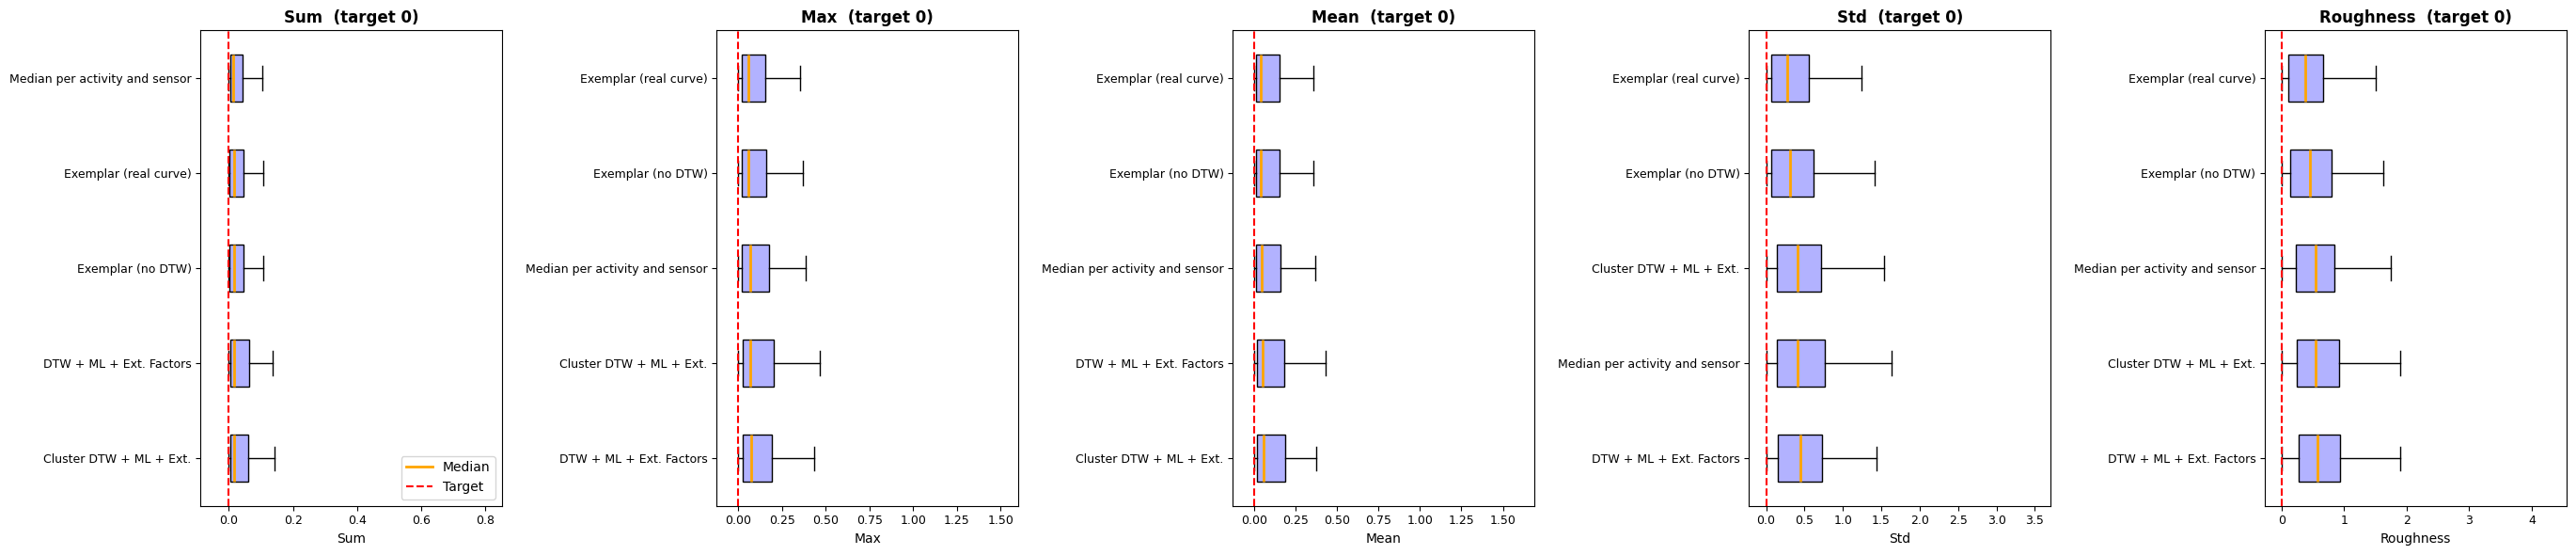

Saved: visuals/individual_profile_realism_boxplot.pdf

% ===== ACCURACY + REALISM, ALL PROCESSES =====
\begin{table*}[H]
\centering

\begin{minipage}{8.5cm}
\centering

\captionsetup{
    justification=centering,
    singlelinecheck=false,
    format=plain
}

\caption{Individual profile prediction: pointwise accuracy and curve realism.}
\label{tab:individual_profile_realism_982}

\vspace{-0.5em}

\begin{tabular}{p{6cm}|c|c|c|c|c|c|c|c|c}
\toprule
\textbf{Method} & \textbf{sMAE} & \textbf{sRMSE} & \textbf{WAPE (\%)} & \textbf{Sum} & \textbf{Max} & \textbf{Mean} & \textbf{Std} & \textbf{Roughness} & \textbf{Overall} \\
\midrule
Median per activity and sensor & \textbf{1.293} & \textbf{1.522} & \textbf{7.820} & \textbf{0.013} & 0.067 & 0.044 & 0.404 & 0.548 & 0.215 \\
Cluster DTW + ML + Ext. & 1.387 & 1.630 & 8.301 & 0.016 & 0.069 & 0.056 & 0.404 & 0.550 & 0.219 \\
Exemplar (no DTW) & 1.409 & 1.681 & 9.118 & 0.015 & 0.060 & \textbf{0.043} & 0.317 & 0.451 & 0.177 \\
Exemplar (real curve) &

In [7]:
# Per-process realism, realism boxplots, and the LaTeX float — all gated the
# same way, so an older parquet just prints the skip note.
if not ACTIVE_REALISM:
    display(Markdown('> **Skipped — no realism metrics in this run.**'))
else:
    per_process_realism = {}
    for proc in sorted(combo['Process'].unique()):
        t = approach_table(combo[combo['Process'] == proc], metrics=ACTIVE_REALISM)
        per_process_realism[proc] = t
        display(Markdown(f'### {proc}'))
        display(style_realism(t))

    # ── Boxplots: one panel per realism metric, target drawn as a red line ───
    # The spread matters as much as the median here — a method can land on the
    # target on average while being wildly wrong cell by cell.
    _dfb = combo[~combo['Approach'].isin(EXCLUDE_APPROACHES)]
    fig, axes = plt.subplots(1, len(ACTIVE_REALISM),
                             figsize=(5.5 * len(ACTIVE_REALISM), 6))
    axes = np.atleast_1d(axes)
    _blue = mcolors.to_rgba('blue', alpha=0.3)
    for ax, metric in zip(axes, ACTIVE_REALISM):
        tgt = REALISM_TARGET[metric]
        order = ((_dfb.groupby('Approach')[metric].median() - tgt).abs()
                 .sort_values(ascending=False).index.tolist())
        data = [_dfb.loc[_dfb['Approach'] == a, metric].dropna().values for a in order]
        bp = ax.boxplot(data, tick_labels=order, showfliers=False, vert=False,
                        patch_artist=True, medianprops=dict(color='orange', linewidth=2))
        for patch in bp['boxes']:
            patch.set_facecolor(_blue); patch.set_edgecolor('black')
        ax.axvline(tgt, color='red', linestyle='--', linewidth=1.5)
        av = np.concatenate([d for d in data if len(d)]) if any(len(d) for d in data) else None
        if av is not None and len(av):
            lo, hi = np.percentile(av, [2, 98])
            ax.set_xlim(min(lo, tgt) - 0.05 * abs(hi - lo + 1),
                        max(hi, tgt) + 0.05 * abs(hi - lo + 1))
        ax.set_xlabel(metric); ax.set_title(f'{metric}  (target {tgt:g})', fontweight='bold')
        ax.tick_params(labelsize=9)
    axes[0].legend(handles=[Line2D([0], [0], color='orange', lw=2, label='Median'),
                            Line2D([0], [0], color='red', ls='--', lw=1.5, label='Target')],
                   loc='lower right')
    fig.tight_layout()
    Path('visuals').mkdir(exist_ok=True)
    fig.savefig('visuals/individual_profile_realism_boxplot.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: visuals/individual_profile_realism_boxplot.pdf')

    # ── LaTeX: pointwise and realism side by side, the table for the paper ───
    combined = agg.join(realism_median, how='left')
    print('\n% ===== ACCURACY + REALISM, ALL PROCESSES =====')
    print(to_latex_paper(
        combined,
        caption='Individual profile prediction: pointwise accuracy and curve realism.',
        label=f'tab:individual_profile_realism_{EXPERIMENT}',
        note=('Left block: standardized pointwise error (lower is better). Right block: '
              'realism, each the median over (process, activity, sensor) of the '
              'per-curve relative error |f(pred)-f(real)|/mean|f(real)|, so 0 is '
              'perfect and lower is better -- the same estimator as the '
              'complete-profile results.\n'
              r'\textbf{Bold} marks the best value per column — the minimum for the error '
              'columns, the closest to target for the realism ones.\n'
              'Pointwise error cannot distinguish a usable load profile from a flat line '
              'through the middle of one, so the two blocks must be read together.')))

## 2 · Per process (all methods)

In [8]:
per_process = {}
for proc in sorted(combo['Process'].unique()):
    t = approach_table(combo[combo['Process'] == proc])
    per_process[proc] = t
    display(Markdown(f'### {proc}'))
    display(style_table(t))

### process_1

,sMAE,sRMSE,WAPE
Approach,,,
Median per activity and sensor,0.840,1.040,7.702
DTW + ML + Ext. Factors,0.848,1.044,7.795
Cluster DTW + ML + Ext.,0.867,1.076,7.975
Exemplar (no DTW),0.982,1.220,8.896
Exemplar (real curve),1.024,1.248,9.094


### process_2

,sMAE,sRMSE,WAPE
Approach,,,
Median per activity and sensor,0.479,0.949,64.294
DTW + ML + Ext. Factors,0.514,1.044,84.744
Cluster DTW + ML + Ext.,0.533,1.009,70.214
Exemplar (no DTW),0.657,1.009,70.879
Exemplar (real curve),0.722,1.009,76.041


### process_3

...

,sMAE,sRMSE,WAPE
Approach,,,
Exemplar (real curve),1.828,2.134,6.694
Exemplar (no DTW),1.838,2.134,6.632
Median per activity and sensor,1.974,2.246,7.539
DTW + ML + Ext. Factors,2.408,2.604,10.326
Cluster DTW + ML + Ext.,2.453,2.625,9.604


### process_4_2

,sMAE,sRMSE,WAPE
Approach,,,
Exemplar (real curve),3.253,3.314,7.626
Exemplar (no DTW),3.253,3.314,7.626
Median per activity and sensor,3.336,3.407,12.662
Cluster DTW + ML + Ext.,3.575,3.726,9.527
DTW + ML + Ext. Factors,3.719,3.849,9.312


### process_5

,sMAE,sRMSE,WAPE
Approach,,,
DTW + ML + Ext. Factors,1.843,2.125,7.211
Median per activity and sensor,1.981,2.171,6.129
Cluster DTW + ML + Ext.,1.985,2.279,7.843
Exemplar (no DTW),2.045,2.333,7.857
Exemplar (real curve),2.186,2.332,7.860


## 3 · LaTeX

In [9]:
# LaTeX is printed only — no process_metrics_tables/ folder is written.
# The aggregated table is emitted in the paper layout (table* + minipage + note);
# the per-process ones stay in the plain compact layout.

AGG_LABEL = 'tab:energy_results_median_overall'   # label the paper \ref's

tex_agg = to_latex_paper(agg,
    caption='Results for individual profile prediction. ',
    label=AGG_LABEL,
    note=('Standardized median test results per method, across sensors and activities.\n'
          'Lower values are better. Rows are sorted best-to-worst by sMAE.\n'
          r'\textbf{Bold} indicates the best value per metric. The baseline is the '
          'median value of the sensor.'))
print('% ===== ALL PROCESSES ====='); print(tex_agg)

for proc, t in per_process.items():
    tex = to_latex(t,
        caption=(f'Individual energy-profile prediction for {_tex(proc)} ({SPLIT} set). Median over '
                 r'(activity, sensor) of each curve metric; lower is better. '
                 r'\textbf{Bold} = best approach per metric.'),
        label=f'tab:individual_profile_{proc}_{EXPERIMENT}')
    print(f'\n% ===== {proc} ====='); print(tex)


% ===== ALL PROCESSES =====
\begin{table*}[H]
\centering

\begin{minipage}{8.5cm}
\centering

\captionsetup{
    justification=centering,
    singlelinecheck=false,
    format=plain
}

\caption{Results for individual profile prediction. }
\label{tab:energy_results_median_overall}

\vspace{-0.5em}

\begin{tabular}{p{6cm}|c|c|c}
\toprule
\textbf{Method} & \textbf{sMAE} & \textbf{sRMSE} & \textbf{WAPE (\%)} \\
\midrule
Median per activity and sensor & \textbf{1.293} & \textbf{1.522} & \textbf{7.820} \\
Cluster DTW + ML + Ext. & 1.387 & 1.630 & 8.301 \\
Exemplar (no DTW) & 1.409 & 1.681 & 9.118 \\
Exemplar (real curve) & 1.417 & 1.713 & 9.275 \\
DTW + ML + Ext. Factors & 1.418 & 1.619 & 8.069 \\
\bottomrule
\end{tabular}

\vspace{0.5em}

\parbox{12cm}{%
\footnotesize
Standardized median test results per method, across sensors and activities.
Lower values are better. Rows are sorted best-to-worst by sMAE.
\textbf{Bold} indicates the best value per metric. The baseline is the median value of

## 4 · Boxplot — aggregated per (process, activity, sensor)

Same style as the sMAE boxplot in `results_latex_table`: one box per approach over
all (process, activity, sensor) values, sorted best-at-top, x-axis capped near the
95th percentile.

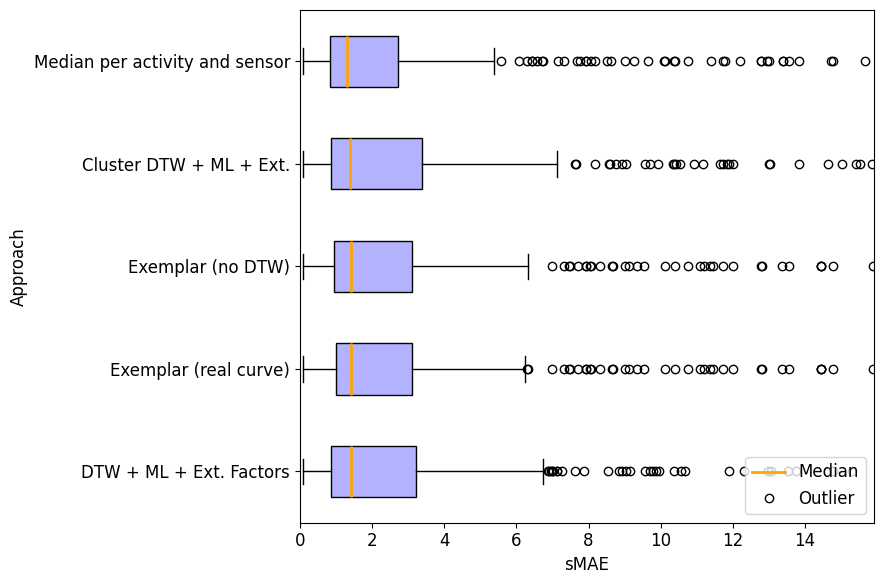

Saved: visuals/individual_profile_sMAE_boxplot.pdf


In [10]:
plt.rcParams.update({'font.size': 12})
df_box = combo[~combo['Approach'].isin(EXCLUDE_APPROACHES)]
box_order = df_box.groupby('Approach')[BOX_METRIC].median().sort_values(ascending=False).index.tolist()
data = [df_box.loc[df_box['Approach'] == a, BOX_METRIC].dropna().values for a in box_order]

fig, ax = plt.subplots(figsize=(9, 6))
bplot = ax.boxplot(data, tick_labels=box_order, showfliers=True, vert=False,
                   patch_artist=True, medianprops=dict(color='orange', linewidth=2))
blue_rgba = mcolors.to_rgba('blue', alpha=0.3)
for patch in bplot['boxes']:
    patch.set_facecolor(blue_rgba); patch.set_edgecolor('black')
all_vals = np.concatenate([d for d in data if len(d)])
ax.set_xlim(0, np.percentile(all_vals, 95) * 1.3)
ax.set_xlabel(BOX_METRIC); ax.set_ylabel('Approach')
ax.legend(handles=[Line2D([0],[0],color='orange',lw=2,label='Median'),
                   Line2D([0],[0],marker='o',color='w',markeredgecolor='black',
                          markerfacecolor='none',markersize=6,label='Outlier')], loc='lower right')
fig.tight_layout()
Path('visuals').mkdir(exist_ok=True)
fig.savefig(f'visuals/individual_profile_{BOX_METRIC}_boxplot.pdf', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: visuals/individual_profile_{BOX_METRIC}_boxplot.pdf')

### Boxplots for every metric

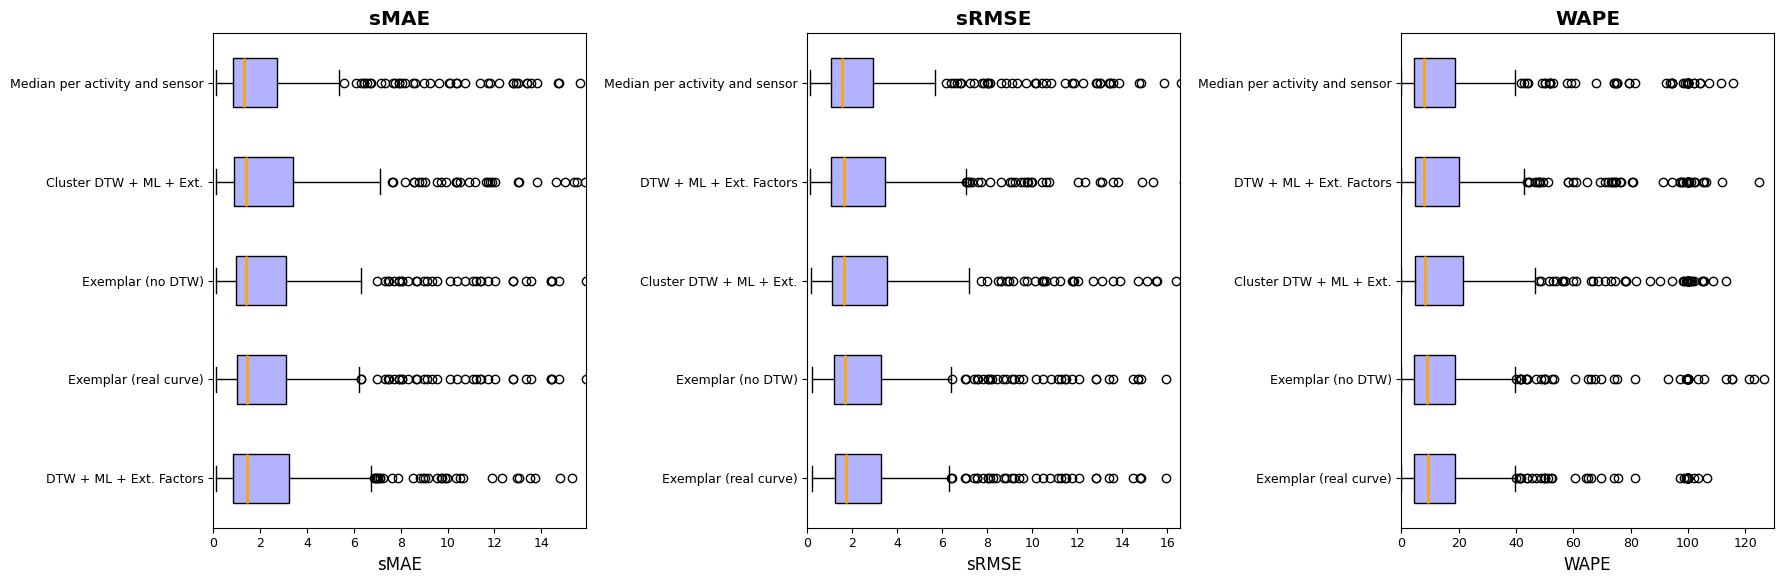

In [11]:
metrics = METRICS
fig, axes = plt.subplots(1, len(metrics), figsize=(6*len(metrics), 6))
axes = np.atleast_1d(axes)
for ax, metric in zip(axes, metrics):
    order = df_box.groupby('Approach')[metric].median().sort_values(ascending=False).index.tolist()
    data = [df_box.loc[df_box['Approach'] == a, metric].dropna().values for a in order]
    bp = ax.boxplot(data, tick_labels=order, showfliers=True, vert=False,
                    patch_artist=True, medianprops=dict(color='orange', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(blue_rgba); patch.set_edgecolor('black')
    av = np.concatenate([d for d in data if len(d)])
    if len(av): ax.set_xlim(0, np.percentile(av, 95) * 1.3)
    ax.set_xlabel(metric); ax.set_title(metric, fontweight='bold')
    ax.tick_params(labelsize=9)
fig.tight_layout()
plt.show()